# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [1]:
# Add auto reload:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FixedLocator

In [3]:
pulse_sequence = [[[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0], [4936, 2690399, 2745087, 2825086, 2892085, 2972084, 3039083, 3119082, 3186081, 3266080, 3333079, 3413078, 7980077, 8047076, 8127075, 8194074, 8274073, 8341072, 8421071, 8488070, 8568069, 8635068, 8715067, 8782066, 8867247, 13603791, 13649575, 13957431, 14087437, 14375239, 14483087, 14561614, 14869471, 14999478, 15287271, 15398791], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 34000, 99999, 68000, 68000, 99999, 68000, 99999, 68000, 68000, 99999, 34000], [80000000, 79972625, 79989657, 80002065, 80006393, 79985329, 80023129, 79968593, 80039865, 79951857, 80056601, 79935121, 80112045, 79896413, 80095309, 79913149, 80078573, 79929886, 80061837, 79946622, 80045101, 79963358, 80028365, 79980094, 80012347, 79931193, 80060881, 79945028, 79943203, 80070870, 79918648, 80073487, 79932222, 79930397, 80082676, 79906060], [200000000, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200005800, 200000500, 200005800, 200000500, 200005800, 200005800, 200000500, 200005800], [99480600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], [[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0], [4936, 2690399, 2945087, 3025086, 3092085, 3172084, 3239083, 3319082, 3386081, 3466080, 3533079, 3613078, 8180077, 8247076, 8327075, 8394074, 8474073, 8541072, 8621071, 8688070, 8768069, 8835068, 8915067, 8982066, 9067247, 13803791, 13849575, 14157431, 14287437, 14575239, 14683087, 14761614, 15069471, 15199478, 15487271, 15598791], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 34000, 99999, 68000, 68000, 99999, 68000, 99999, 68000, 68000, 99999, 34000], [80000000, 79972625, 79986849, 80004873, 80003585, 79988137, 80020321, 79971401, 80037057, 79954665, 80053793, 79937929, 80114853, 79893605, 80098117, 79910341, 80081381, 79927077, 80064645, 79943813, 80047909, 79960550, 80031173, 79977286, 80015155, 79928385, 80063690, 79942220, 79940395, 80073678, 79915839, 80076295, 79929414, 79927589, 80085484, 79903251], [200000500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200005800, 200000500, 200005800, 200000500, 200005800, 200005800, 200000500, 200005800], [99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600, 99478600], [2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]]]

In [4]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    switch_hz,
    delivery_hz,
    delivery_setpoint
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
switch_hz = np.array(switch_hz)
delivery_hz = np.array(delivery_hz)
delivery_setpoint = np.array(delivery_setpoint)

# --- Correct the recorded shelving-pulse OPLL to its pulse-centre value ---
# This dump predates centre-of-pulse reporting in the lab's pulse recorder
# (PulseDMARecording.register_pulse in icl_experiments now records the OPLL
# frequency averaged over the pulse). The 380 us velocity-selection pulse
# fires while the clock OPLL is ramping at the gravity rate (clock_shelving.py
# starts the DRG ramp immediately before it), so the recorded START value is
# below the pulse-centre value by ramp_rate * duration / 2 ~ 2.7 kHz
# (0.57 recoil). The LMT pi pulses are fired with a STATIC OPLL
# (LMT_launch_mixins.fire_lmt_pulse) and need no correction.
opll_hz = opll_hz.astype(float)
opll_hz[0] += sim.GRAVITY_DOPPLER_PER_SEC_HZ * durations_mu[0] * 1e-9 / 2

In [5]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [6]:
# Cut after the launch

t_launch_finished = 5e-3

is_before_launch = start_times_mu * 1e-9 < t_launch_finished

is_up = is_up[is_before_launch]
start_times_mu = start_times_mu[is_before_launch]
durations_mu = durations_mu[is_before_launch]
opll_hz = opll_hz[is_before_launch]
switch_hz = switch_hz[is_before_launch]
delivery_hz = delivery_hz[is_before_launch]
delivery_setpoint = delivery_setpoint[is_before_launch]

In [7]:
# --- HACKY AUTO-CALIBRATION (a warning is emitted at runtime) ---
# alpha (probe-shift coefficient) and v0 (initial atom velocity) used to be
# hand-tuned magic numbers. Instead we now back them out of the lab pulse dump:
# alpha from how the up-beam pulses sit relative to each other vs their Rabi
# frequency, and v0 from the residual up/down detuning once alpha is applied.
# This is a self-consistent fit, NOT a measurement -- replace with real
# light-shift and launch-velocity calibrations.
# probe_shift_alpha, initial_velocity_z = (
#     seq.calibrate_probe_shift_and_velocity_from_dump(
#         is_up=is_up,
#         start_times_mu=start_times_mu,
#         durations_mu=durations_mu,
#         opll_hz=opll_hz,
#         switch_hz=switch_hz,
#         delivery_hz=delivery_hz,
#         delivery_setpoint=delivery_setpoint,
#     )
# )


t_pi_ref = 55e-6


# From measurement - see "2026-06-09 Clock shift gap-filling even Omega2 grid"
# The measurement defined alpha in terms of 1/ (rad/s), so convert to 1/Hz
probe_shift_alpha = -2.04e-6 * (2 * np.pi)
print(f"calibrated probe-shift alpha = {probe_shift_alpha:.4e} Hz^-1")

rabi_freq_ref = 1 / (2*t_pi_ref)
probe_shift_ref = probe_shift_alpha * rabi_freq_ref**2
print(f"corresponding probe shift at Rabi frequency {rabi_freq_ref:.1f} Hz is {probe_shift_ref:.1f} Hz")


calibrated probe-shift alpha = -1.2818e-05 Hz^-1
corresponding probe shift at Rabi frequency 9090.9 Hz is -1059.3 Hz


In [8]:
# Pin initial_velocity_z so the first DOWN pulse is resonant on its intended
# rung. The parser anchors everything on the first (up) pulse, so the only
# leftover beam-asymmetric term is the 2*v0/lambda Doppler split between the
# counter-propagating beams. Same logic as
# seq.calibrate_probe_shift_and_velocity_from_dump, but holding alpha at the
# measured value above instead of fitting it. (Replaces an old hand-tuned
# FIXME value.)
_, _bare = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    probe_induced_alpha_up=0.0,
    probe_induced_alpha_down=0.0,
    initial_velocity_z=0.0,
)
_pulses = [e for e in _bare if isinstance(e, seq.Pulse)]
_anchor = _pulses[0]
_first_opposite = next(p for p in _pulses if p.k == -_anchor.k)
_anchor_rabi = _anchor.rabi_frequency
initial_velocity_z = (
    _anchor.k
    * 0.5
    * sim.TRANSITION_WAVELENGTH
    * (
        _anchor.detuning_hz
        - _first_opposite.detuning_hz
        - 4 * sim.RECOIL_FREQUENCY_HZ
        - probe_shift_alpha
        * (_anchor_rabi**2 - _first_opposite.rabi_frequency**2)
    )
)
print(f"initial_velocity_z = {initial_velocity_z * 1e3:+.3f} mm/s")

initial_velocity_z = -1.733 mm/s


In [9]:
_, sequence = seq.build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    switch_hz=switch_hz,
    delivery_hz=delivery_hz,
    delivery_setpoint=delivery_setpoint,
    initial_velocity_z=initial_velocity_z,
    probe_induced_alpha_up=probe_shift_alpha,
    probe_induced_alpha_down=probe_shift_alpha,
)


In [10]:
def plot_lab_pulse_sequence(plot_sequence, plot_corrected=True, plot_by_timestamp=False):
    raw_detunings_recoil = []
    corrected_detunings_recoil = []
    pulse_colours = []
    pulse_hatches = []
    clearout_links = []

    last_pulse_index = None
    clearout_since_last_pulse = False

    PULSE_STYLES = {
        #              colour          hatch
        (True, True): ("tab:orange", ""),  # up,   pi
        (True, False): ("tab:blue", "///"),  # up,   pi/2
        (False, True): ("tab:red", "\\\\"),  # down, pi
        (False, False): ("tab:purple", "xxx"),  # down, pi/2
    }

    timestamps = []
    pulse_durations = []
    now = 0.0
    for event in plot_sequence:
        if isinstance(event, seq.Clearout):
            clearout_since_last_pulse = True
            now += event.duration
            continue

        if not isinstance(event, seq.Pulse):
            now += event.duration
            continue

        timestamps.append(now + event.duration / 2)
        pulse_durations.append(event.duration)
        now += event.duration

        pulse_index = len(raw_detunings_recoil)
        raw_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
        probe_shift_hz = (
            event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
        )
        corrected_detunings_recoil.append(
            (event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ
        )

        colour, hatch = PULSE_STYLES[(event.k == 1, is_pi_pulse(event.duration))]
        pulse_colours.append(colour)
        pulse_hatches.append(hatch)

        if last_pulse_index is not None and clearout_since_last_pulse:
            clearout_links.append((last_pulse_index, pulse_index))

        last_pulse_index = pulse_index
        clearout_since_last_pulse = False

    pulse_indices = np.arange(len(raw_detunings_recoil))

    fig, ax = plt.subplots(figsize=(18, 10))
    plot_detunings = (
        corrected_detunings_recoil if plot_corrected else raw_detunings_recoil
    )

    x_axis = timestamps if plot_by_timestamp else pulse_indices

    bars = ax.bar(x_axis, plot_detunings, color=pulse_colours, width= pulse_durations if plot_by_timestamp else 0.9)
    for bar, hatch in zip(bars, pulse_hatches):
        bar.set_hatch(hatch)

    for left_index, right_index in clearout_links:
        ax.plot(
            [x_axis[left_index], x_axis[right_index]],
            [
                plot_detunings[left_index],
                plot_detunings[right_index],
            ],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            zorder=3,
        )

    if not plot_by_timestamp:
        tick_step = max(1, len(pulse_indices) // 20)
        ax.set_xticks(pulse_indices[::tick_step])
        ax.set_xlabel("Pulse index")
    else:
        ax.set_xlabel("Time (s)")
    ax.set_ylabel("Detuning (recoil frequencies)")

    # Show where the uncorrected (raw) detuning sat, for comparison.
    if plot_corrected:
        ax.scatter(
            x_axis,
            raw_detunings_recoil,
            facecolor="none",
            edgecolor="0.2",
            marker="o",
            s=40,
            zorder=4,
        )

    # Horizontal gridlines on the odd integers only.
    y_min, y_max = ax.get_ylim()
    odd_integers = np.arange(np.ceil(y_min), np.floor(y_max) + 1)
    odd_integers = odd_integers[odd_integers % 2 != 0]
    for y in odd_integers:
        ax.axhline(y, color="0.5", linestyle=":", alpha=0.8, zorder=0)
    ax.axhline(0.0, color="0.5", linestyle="-", alpha=0.8, zorder=0)

    legend_handles = [
        Patch(facecolor="tab:orange", hatch="", label="up, pi"),
        Patch(facecolor="tab:blue", hatch="///", label="up, pi/2"),
        Patch(facecolor="tab:red", hatch="\\\\", label="down, pi"),
        Patch(facecolor="tab:purple", hatch="xxx", label="down, pi/2"),
    ]
    if clearout_links:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:green",
                linestyle=":",
                linewidth=2,
                label="clearout between pulses",
            )
        )

    ax.legend(handles=legend_handles, loc="upper left", frameon=False)

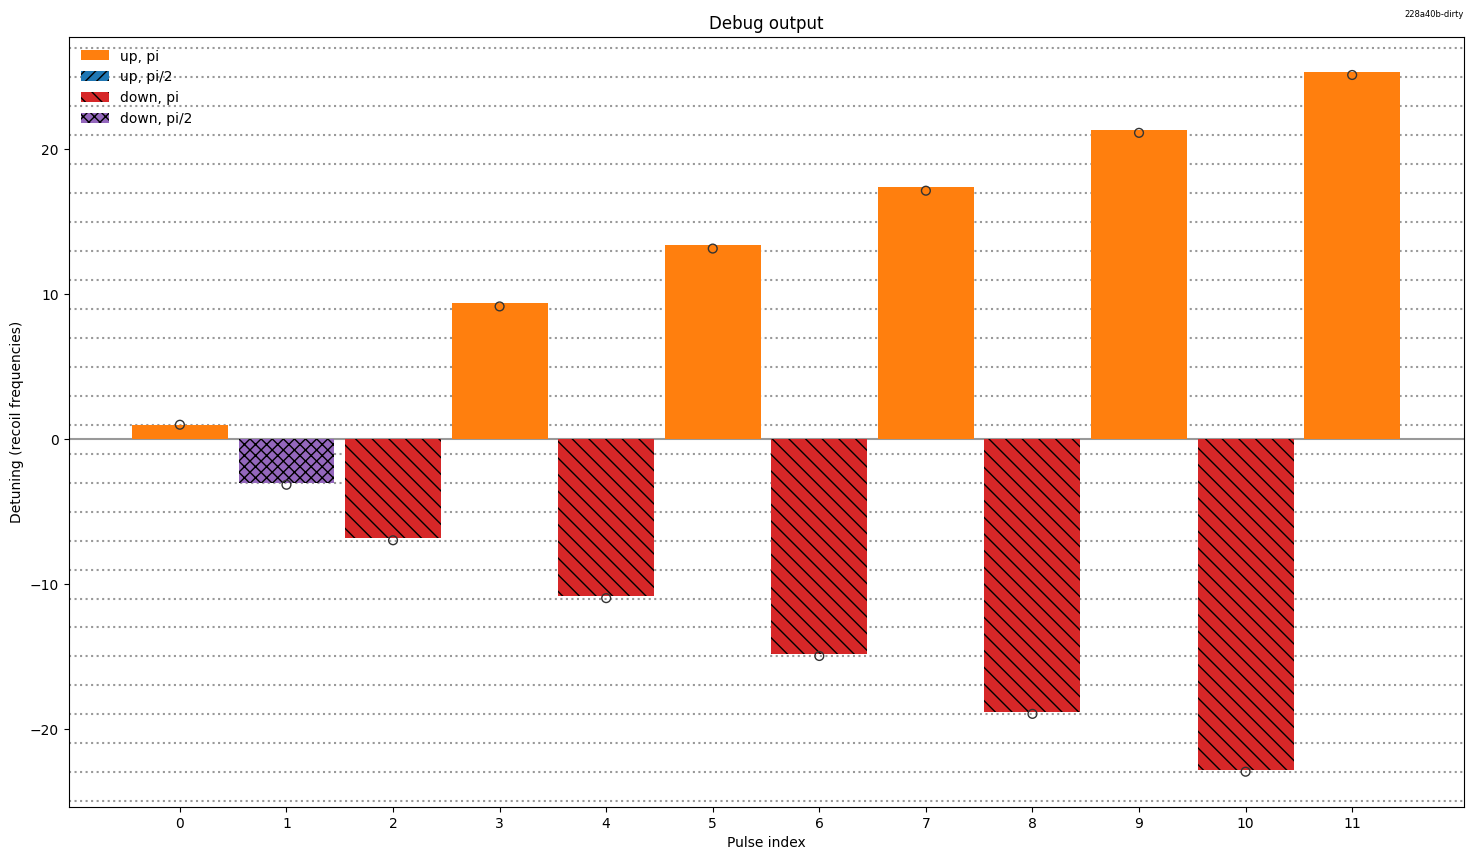

In [11]:
plot_lab_pulse_sequence(sequence, plot_corrected=True)
plt.title("Debug output")
vs.tag_plot(small=True);

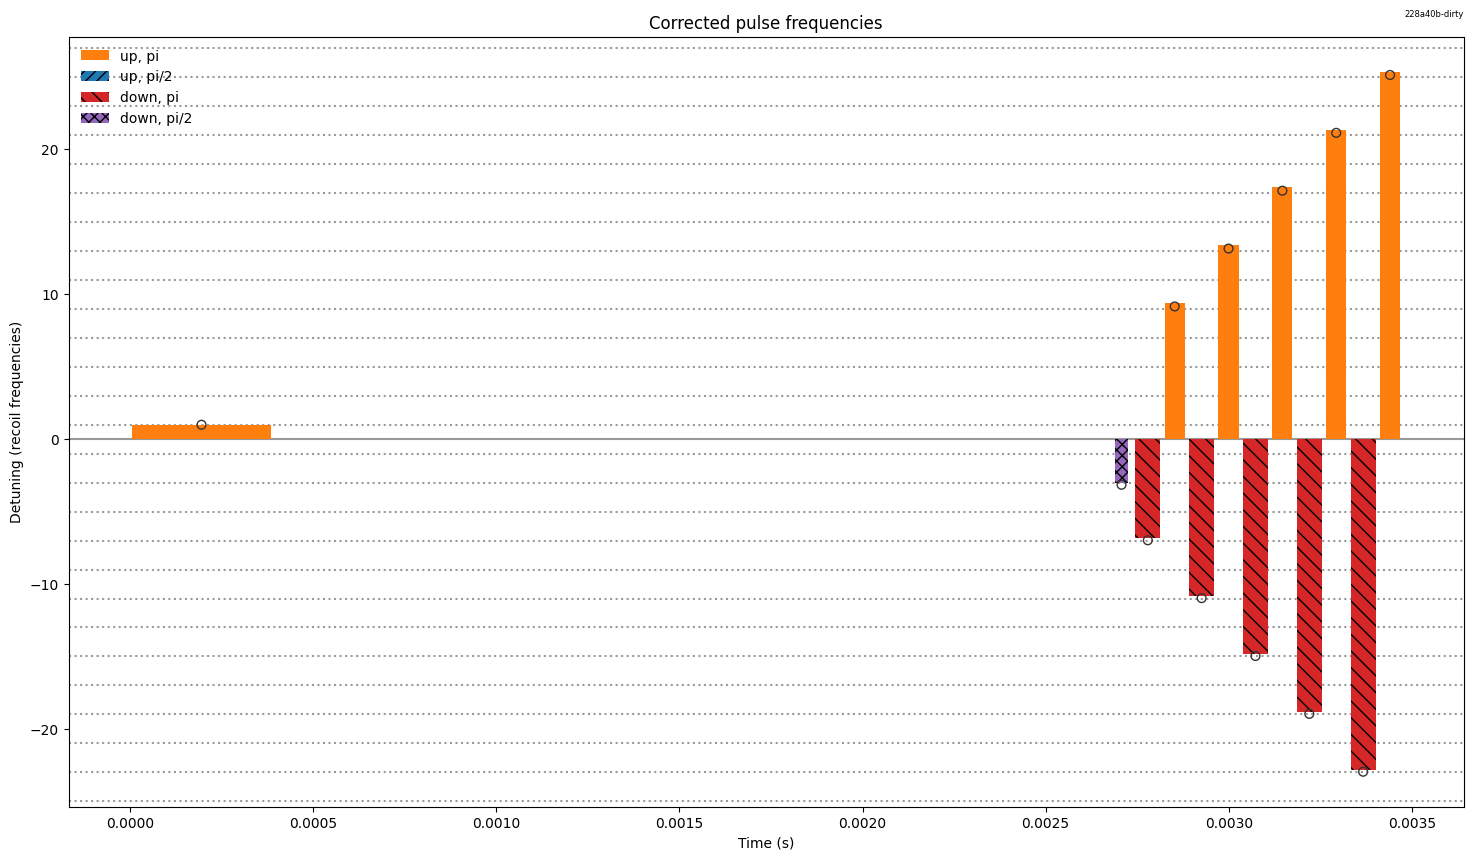

In [12]:
plot_lab_pulse_sequence(sequence, plot_corrected=True, plot_by_timestamp=True)
plt.title("Corrected pulse frequencies")
vs.tag_plot(small=True);

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.002745087), np.float64(0.0028130869999999997), np.float64(0.0028250859999999997), np.float64(0.0028800849999999997), np.float64(0.0028920849999999995), np.float64(0.0029600849999999995), np.float64(0.002972084), np.float64(0.003027083), np.float64(0.0030390829999999997), np.float64(0.0031070829999999996), np.float64(0.0031190819999999996), np.float64(0.0031740809999999996), np.float64(0.003186081), np.float64(0.003254081), np.float64(0.0032660799999999998), np.float64(0.003321079), np.float64(0.0033330789999999996), np.float64(0.0034010789999999996), np.float64(0.003413078), np.float64(0.003468077)], z=[0.0, np.float64(0.0), np.float64(2.4969845359566025e-06), np.float64(1.7646209428641116e-05), np.float64(1.7869623834489865e-05), np.float64(1.8005564929436894e-05), np.float64(1.845239374

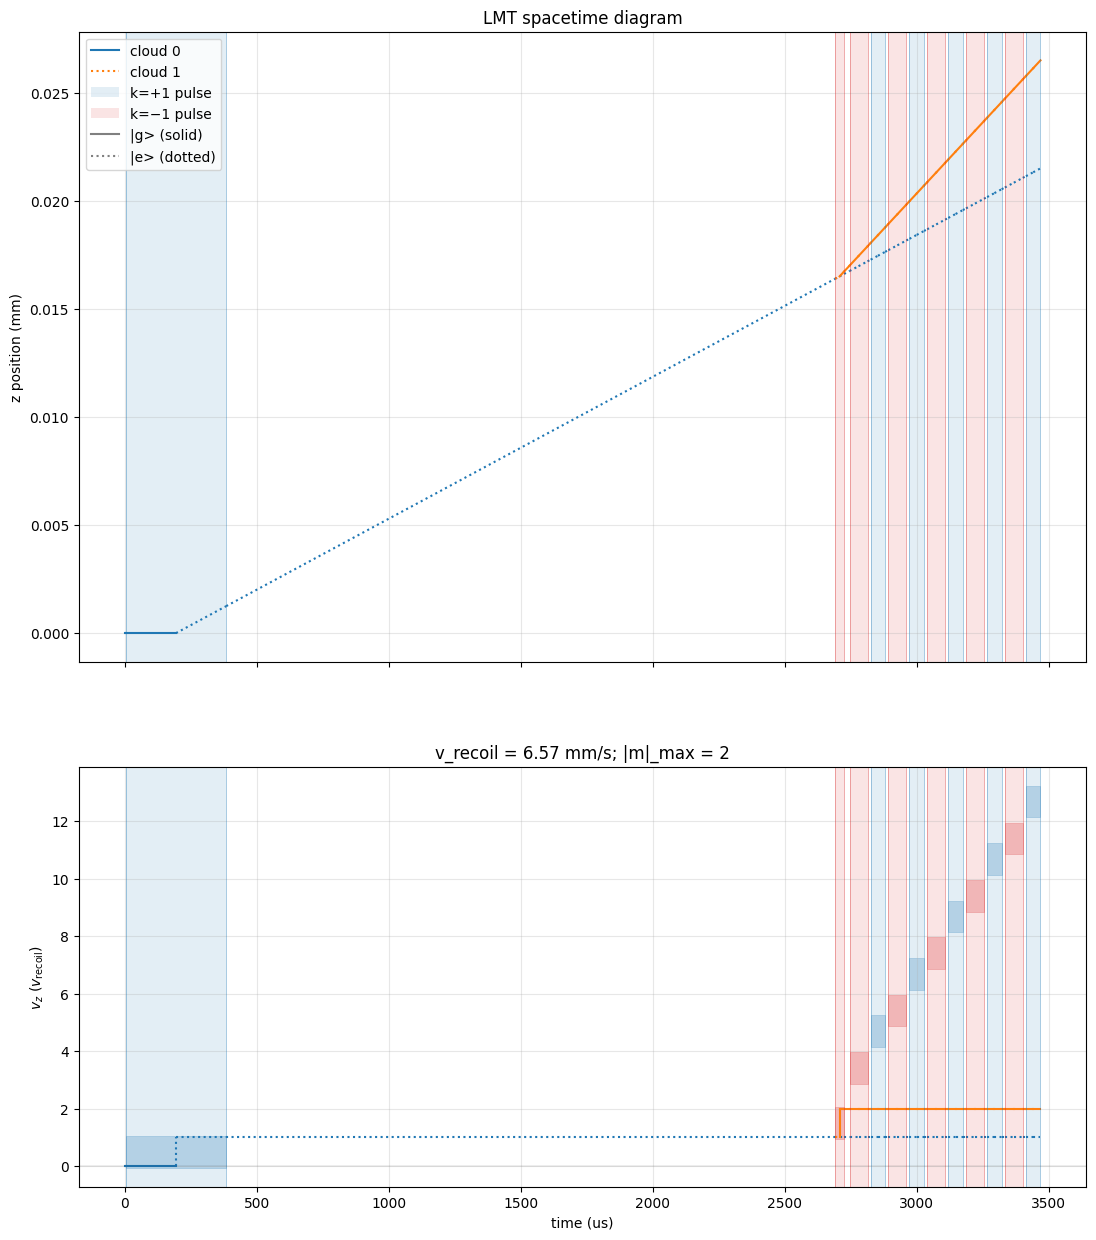

In [13]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)

In [14]:
# Apply a hacky correction - round each pulse to the nearest corrected integer number of recoils
import dataclasses

bodged_sequence = []
for event in sequence:
    if not isinstance(event, seq.Pulse):
        bodged_sequence.append(event)
        continue

    probe_shift_hz = (
        event.probe_shift_coefficient * event.effective_stark_rabi_frequency**2
    )

    closest_integer = int(
        round((event.detuning_hz - probe_shift_hz) / sim.RECOIL_FREQUENCY_HZ)
    )

    # Re-add the probe shift so that the EFFECTIVE detuning (the sim subtracts
    # the shift again during the pulse) lands exactly on the recoil ladder.
    new_pulse = dataclasses.replace(
        event,
        detuning_hz=closest_integer * sim.RECOIL_FREQUENCY_HZ + probe_shift_hz,
    )
    bodged_sequence.append(new_pulse)


([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(4.936000000000001e-06), np.float64(0.000384936), np.float64(0.0026903989999999996), np.float64(0.0027243989999999997), np.float64(0.002745087), np.float64(0.0028130869999999997), np.float64(0.0028250859999999997), np.float64(0.0028800849999999997), np.float64(0.0028920849999999995), np.float64(0.0029600849999999995), np.float64(0.002972084), np.float64(0.003027083), np.float64(0.0030390829999999997), np.float64(0.0031070829999999996), np.float64(0.0031190819999999996), np.float64(0.0031740809999999996), np.float64(0.003186081), np.float64(0.003254081), np.float64(0.0032660799999999998), np.float64(0.003321079), np.float64(0.0033330789999999996), np.float64(0.0034010789999999996), np.float64(0.003413078), np.float64(0.003468077)], z=[0.0, np.float64(0.0), np.float64(2.4969845359566025e-06), np.float64(1.7646209428641116e-05), np.float64(1.7869623834489865e-05), np.float64(1.8005564929436894e-05), np.float64(1.845239374

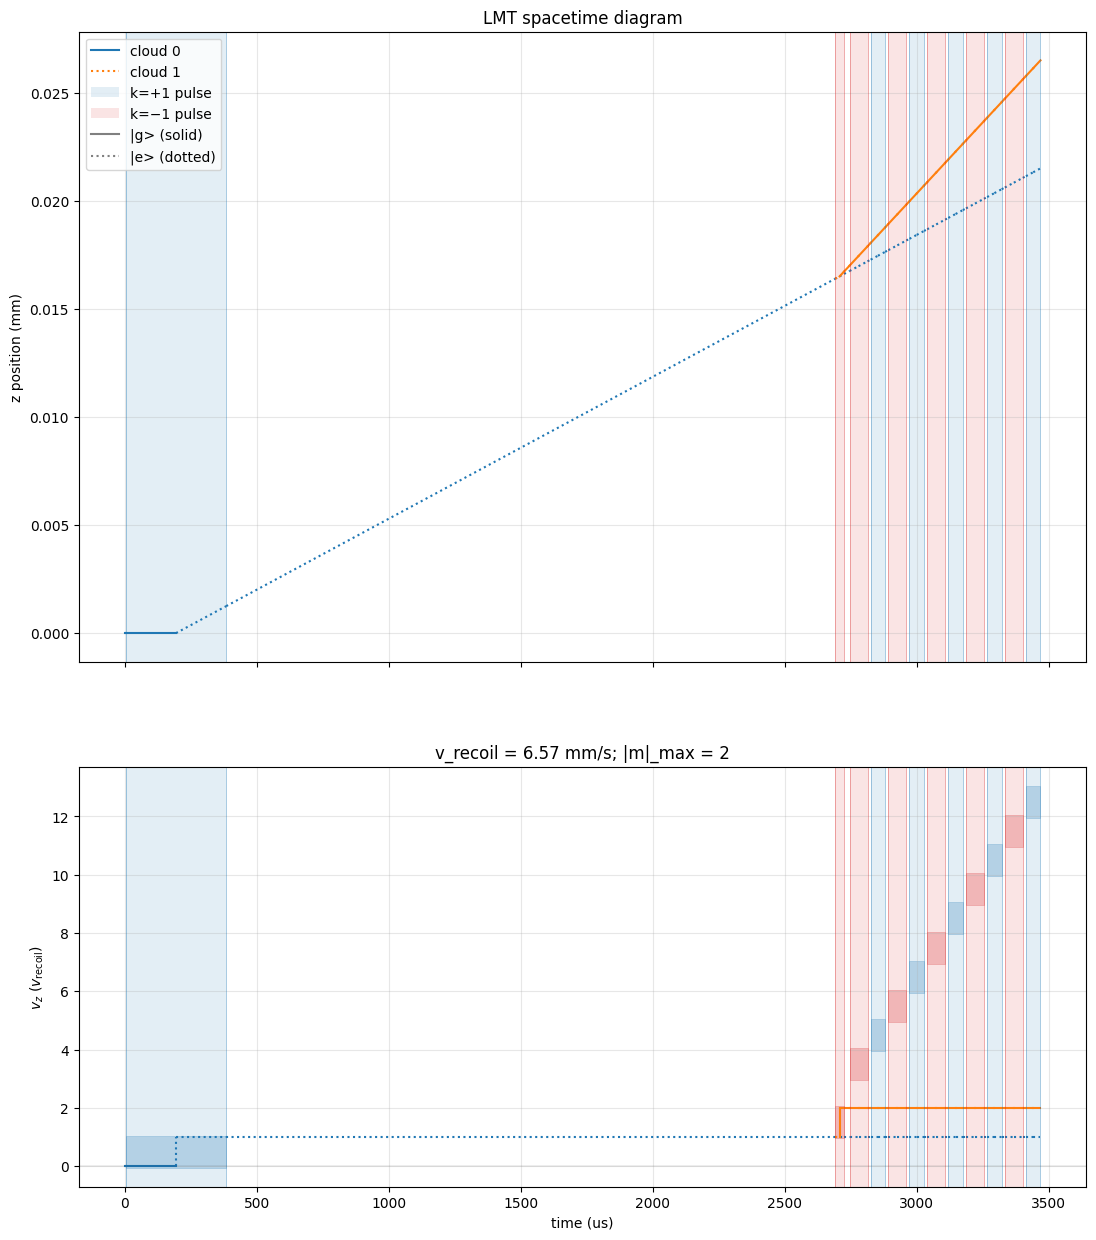

In [15]:
seq.compute_spacetime_trajectory(bodged_sequence, plot=True, max_branches=20)